In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import torch
from torch_geometric.utils import degree
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import networkx as nx
import random
import warnings
warnings.filterwarnings("ignore")

plt.style.use('seaborn-v0_8')


## Load Elliptic Dataset

In [3]:
DATA_DIR = Path('../data/raw')

df_feat = pd.read_csv(DATA_DIR / 'elliptic_txs_features.csv', header=None)
df_class = pd.read_csv(DATA_DIR / 'elliptic_txs_classes.csv')
df_edge = pd.read_csv(DATA_DIR / 'elliptic_txs_edgelist.csv')

tx_ids = df_feat.iloc[:, 0].values
time_steps = df_feat.iloc[:, 1].values
features = df_feat.iloc[:, 2:].values

print(f"Nodes: {len(tx_ids):,}")
print(f"Edges: {len(df_edge):,}")
print(f"Features: {features.shape[1]}")


Nodes: 203,769
Edges: 234,355
Features: 165


## 1. Feature Analysis

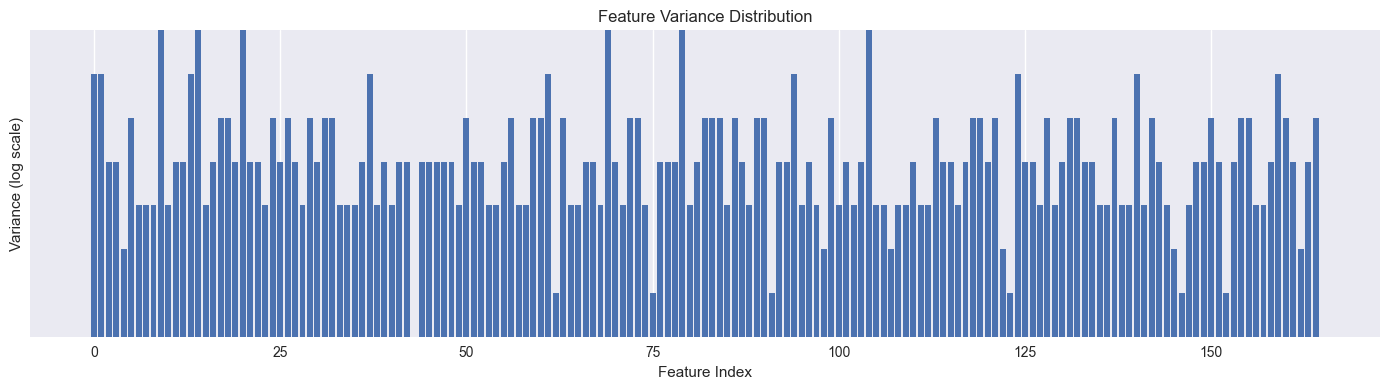

Low-variance features may contribute less to classification.


In [4]:
feat_df = pd.DataFrame(features)

variance = feat_df.var()

plt.figure(figsize=(14,4))
plt.bar(range(len(variance)), variance.values)
plt.yscale('log')
plt.xlabel("Feature Index")
plt.ylabel("Variance (log scale)")
plt.title("Feature Variance Distribution")
plt.tight_layout()
plt.show()

print("Low-variance features may contribute less to classification.")


Explained variance ratio: [0.10482862 0.06091381]


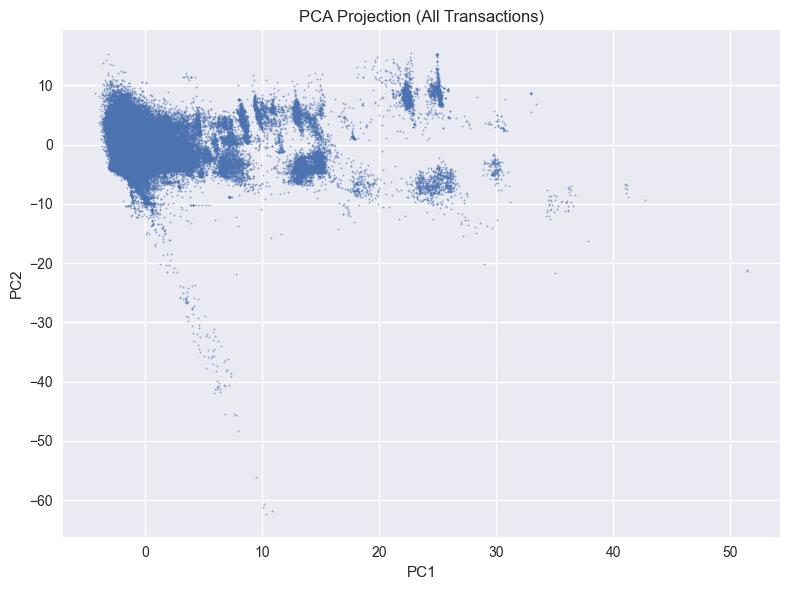

In [5]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(features)

print("Explained variance ratio:", pca.explained_variance_ratio_)

plt.figure(figsize=(8,6))
plt.scatter(pca_result[:,0], pca_result[:,1], s=1, alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (All Transactions)")
plt.tight_layout()
plt.show()


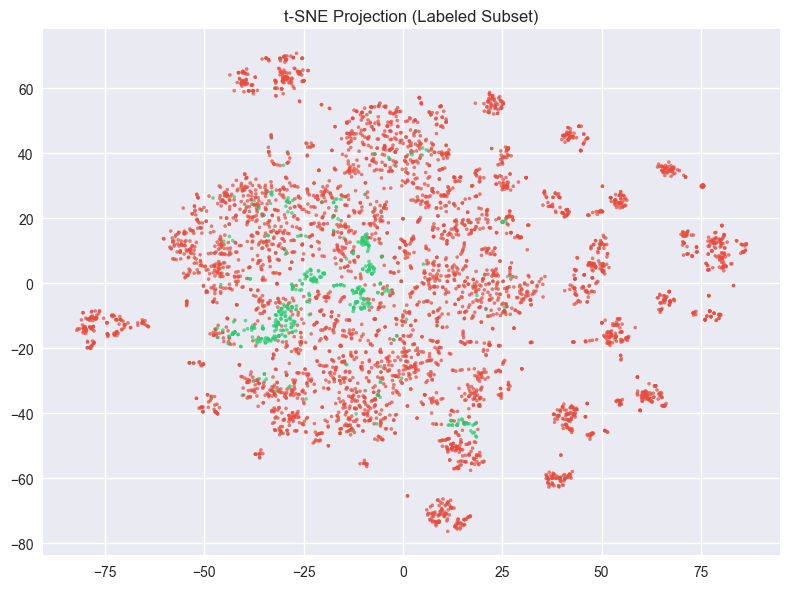

In [6]:
class_map = df_class.set_index('txId')['class'].to_dict()
labels = np.array([class_map.get(tx, 'unknown') for tx in tx_ids])

labeled_mask = labels != 'unknown'
labeled_features = features[labeled_mask]
labeled_labels = labels[labeled_mask]

# Subsample for speed
sample_idx = np.random.choice(len(labeled_features), size=5000, replace=False)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)

tsne_result = tsne.fit_transform(labeled_features[sample_idx])

plt.figure(figsize=(8,6))
colors = ['#2ecc71' if l=='1' else '#e74c3c' for l in labeled_labels[sample_idx]]
plt.scatter(tsne_result[:,0], tsne_result[:,1], c=colors, s=5, alpha=0.7)
plt.title("t-SNE Projection (Labeled Subset)")
plt.tight_layout()
plt.show()


## 2. Temporal Analysis

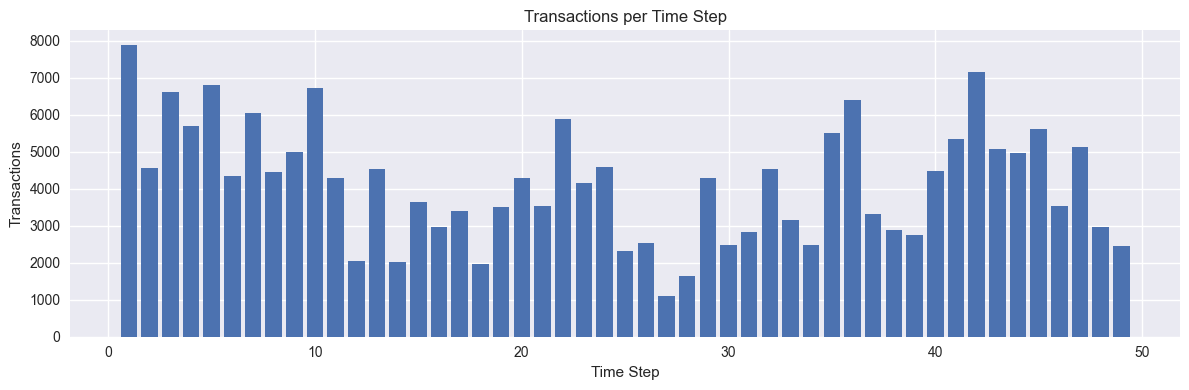

In [7]:
tx_per_step = pd.Series(time_steps).value_counts().sort_index()

plt.figure(figsize=(12,4))
plt.bar(tx_per_step.index, tx_per_step.values)
plt.xlabel("Time Step")
plt.ylabel("Transactions")
plt.title("Transactions per Time Step")
plt.tight_layout()
plt.show()


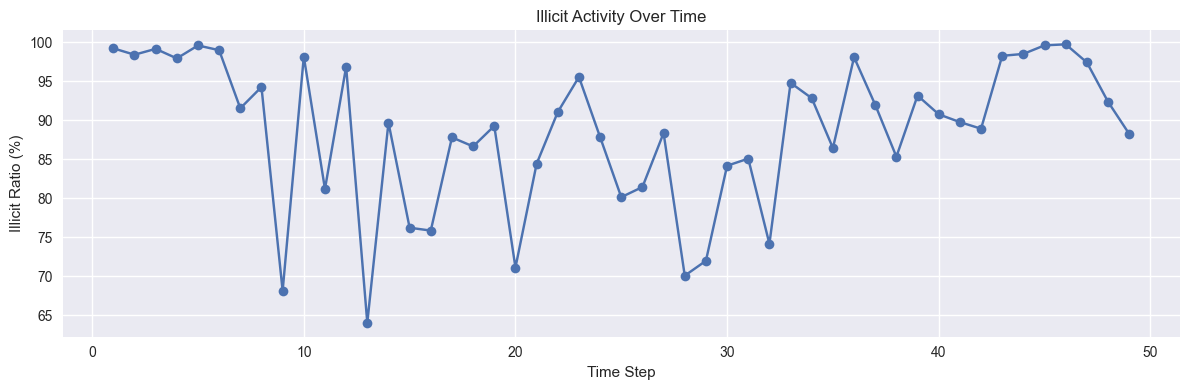

In [8]:
df_temp = pd.DataFrame({'txId': tx_ids, 'time': time_steps})
df_merged = df_temp.merge(df_class, on='txId', how='left')

labeled_df = df_merged[df_merged['class'] != 'unknown'].copy()
labeled_df['class'] = labeled_df['class'].astype(int)
labeled_df['is_illicit'] = (labeled_df['class'] == 2).astype(int)

illicit_time = labeled_df.groupby('time')['is_illicit'].mean() * 100

plt.figure(figsize=(12,4))
plt.plot(illicit_time.index, illicit_time.values, marker='o')
plt.xlabel("Time Step")
plt.ylabel("Illicit Ratio (%)")
plt.title("Illicit Activity Over Time")
plt.tight_layout()
plt.show()


## 3. Network Topology

In [8]:
id_to_idx = {tx: i for i, tx in enumerate(tx_ids)}

edges = [(id_to_idx[s], id_to_idx[d])
         for s, d in zip(df_edge.iloc[:,0], df_edge.iloc[:,1])
         if s in id_to_idx and d in id_to_idx]

G = nx.DiGraph()
G.add_nodes_from(range(len(tx_ids)))
G.add_edges_from(edges)

print("Graph built.")


Graph built.


In [9]:
weak_components = list(nx.weakly_connected_components(G))
print(f"Weakly connected components: {len(weak_components)}")

largest_cc = max(weak_components, key=len)
print(f"Largest component size: {len(largest_cc):,}")


Weakly connected components: 49
Largest component size: 7,880


In [10]:
G_undirected = G.to_undirected()
clustering = nx.average_clustering(G_undirected)

print(f"Average clustering coefficient: {clustering:.4f}")


Average clustering coefficient: 0.0138


In [14]:
largest_subgraph = G_undirected.subgraph(largest_cc)

print("Computing approximate average shortest path length...")

# Sample only a subset of nodes
sample_size = 100
sample_nodes = random.sample(list(largest_subgraph.nodes()), sample_size)

path_lengths = []

for node in sample_nodes:
    lengths = nx.single_source_shortest_path_length(largest_subgraph, node)
    path_lengths.extend(lengths.values())

avg_path = sum(path_lengths) / len(path_lengths)

print(f"Approximate average shortest path length: {avg_path:.2f}")



Computing approximate average shortest path length...
Approximate average shortest path length: 11.07


## Labelled vs Unlabelled

In [12]:
class_counts = df_class['class'].value_counts()

total = len(df_class)
labeled = total - class_counts.get('unknown', 0)

print(f"Total nodes: {total:,}")
print(f"Labeled nodes: {labeled:,} ({labeled/total*100:.2f}%)")
print(f"Unlabeled nodes: {class_counts.get('unknown', 0):,}")


Total nodes: 203,769
Labeled nodes: 46,564 (22.85%)
Unlabeled nodes: 157,205
